In [1]:
# ============================================================
# CELL 1 — Imports & environment check
# ============================================================
import os, json, zipfile, time
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

assert torch.cuda.is_available()
device = torch.device("cuda")
print(torch.__version__, torch.cuda.get_device_name(0))
torch.backends.cudnn.benchmark = True


from modules.datasets import DATASETS

DATA_DIR = DATASETS["ISLR"]


2.13.0+cu130 NVIDIA GeForce RTX 4080 SUPER


In [2]:
# ============================================================
# CELL 2 — Paths & the canonical label map
# ============================================================
# DATA_DIR is a pathlib.Path already pointing at the competition data root.
TRAIN_CSV = DATA_DIR / "train.csv"
LABEL_MAP_PATH = DATA_DIR / "sign_to_prediction_index_map.json"

with open(LABEL_MAP_PATH) as f:
    sign2idx = json.load(
        f
    )  # {"TV": 0, "after": 1, ...} — THIS is the ground-truth ordering
idx2sign = {v: k for k, v in sign2idx.items()}
NUM_CLASSES = len(sign2idx)
print(f"{NUM_CLASSES} classes loaded from official map")

ROWS_PER_FRAME = 543  # fixed, matches the competition's load_relevant_data_subset

250 classes loaded from official map


In [3]:
# ============================================================
# CELL 3 — Metadata + internal train/val split
# (No test set exists — Kaggle grades via submission.zip. This split
#  is purely for us to monitor generalization during training.)
# ============================================================
train_df = pd.read_csv(TRAIN_CSV)

# Sanity check: every sign in train.csv must exist in the official map
missing = set(train_df["sign"].unique()) - set(sign2idx.keys())
assert not missing, f"Signs in train.csv not found in label map: {missing}"

train_df["label"] = train_df["sign"].map(sign2idx)

from sklearn.model_selection import train_test_split

train_split, val_split = train_test_split(
    train_df, test_size=0.1, stratify=train_df["sign"], random_state=42
)
train_split = train_split.reset_index(drop=True)
val_split = val_split.reset_index(drop=True)
print(len(train_split), len(val_split))


85029 9448


In [4]:
# %%
# ============================================================
# CELL 4 — Raw landmark loading: IDENTICAL to the competition's
# load_relevant_data_subset. No landmark selection, no normalization,
# no dropped types. Only unavoidable cleanup: NaN -> 0.
# Uses pyarrow directly instead of pandas (faster per-file read).
# ============================================================
import pyarrow.parquet as pq


def load_relevant_data_subset(pq_path):
    table = pq.read_table(pq_path, columns=["x", "y", "z"])
    data = np.column_stack([table.column(c).to_numpy() for c in ("x", "y", "z")])
    n_frames = data.shape[0] // ROWS_PER_FRAME
    return data.reshape(n_frames, ROWS_PER_FRAME, 3).astype(np.float32)


def load_and_clean(pq_path):
    arr = load_relevant_data_subset(pq_path)
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    return arr  # (T, 543, 3)


In [5]:
# ============================================================
# CELL 4b — One-time cache build: decode every parquet file once,
# pack into a single flat memmapped float32 array + offsets index.
# Re-running is a no-op if the cache already exists.
# ============================================================
CACHE_DIR = Path("cache")
CACHE_DIR.mkdir(exist_ok=True)


def build_cache(df, data_dir, out_prefix):
    data_path = CACHE_DIR / f"{out_prefix}_data.npy"
    offsets_path = CACHE_DIR / f"{out_prefix}_offsets.npy"
    if data_path.exists() and offsets_path.exists():
        print(f"{out_prefix}: cache already exists, skipping")
        return

    offsets = [0]
    chunks = []
    for path in tqdm(df["path"], desc=f"caching {out_prefix}"):
        arr = load_and_clean(data_dir / path)  # (T, 543, 3), NaN already cleaned
        chunks.append(arr.reshape(-1))
        offsets.append(offsets[-1] + arr.shape[0])

    flat = np.concatenate(chunks).astype(np.float32)
    np.save(data_path, flat)
    np.save(offsets_path, np.array(offsets, dtype=np.int64))
    print(f"{out_prefix}: cached {len(df)} samples, {flat.nbytes / 1e9:.2f} GB")


build_cache(train_split, DATA_DIR, "train")
build_cache(val_split, DATA_DIR, "val")


train: cache already exists, skipping
val: cache already exists, skipping


In [6]:
# %%
# ============================================================
# CELL 5 — Dataset (imported from modules/dataset.py so Windows'
# spawn-based multiprocessing can pickle it correctly for workers)
# ============================================================
from modules.dataset import GISLRRawDataset, collate_fn


In [7]:
# %%
# ============================================================
# CELL 6 — Collate + config
# ============================================================
FEATURE_DIM = ROWS_PER_FRAME * 3

HYP = dict(
    batch_size=192,
    hidden_size=256,
    num_layers=2,
    dropout=0.3,
    lr=3e-4,
    weight_decay=1e-4,
    epochs=60,
    max_seq_len=128,
    grad_clip=5.0,
    num_workers=8,  # set to 0 to test without multiprocessing
)

train_ds = GISLRRawDataset(
    train_split, CACHE_DIR, "train", ROWS_PER_FRAME, HYP["max_seq_len"]
)
val_ds = GISLRRawDataset(
    val_split, CACHE_DIR, "val", ROWS_PER_FRAME, HYP["max_seq_len"]
)

loader_kwargs = dict(
    collate_fn=collate_fn,
    num_workers=HYP["num_workers"],
    pin_memory=True,
)
if HYP["num_workers"] > 0:
    loader_kwargs["persistent_workers"] = True
    loader_kwargs["prefetch_factor"] = 4

train_loader = DataLoader(
    train_ds, batch_size=HYP["batch_size"], shuffle=True, **loader_kwargs
)
val_loader = DataLoader(
    val_ds, batch_size=HYP["batch_size"], shuffle=False, **loader_kwargs
)


In [8]:
# ============================================================
# CELL 7 — Model (unidirectional GRU, unchanged architecture choice)
# ============================================================
class StreamingGRU(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.3):
        super().__init__()
        self.input_norm = nn.LayerNorm(input_size)
        self.gru = nn.GRU(
            input_size,
            hidden_size,
            num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=False,
        )
        self.head = nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, num_classes),
        )

    def forward(self, x, lengths, hidden=None):
        x = self.input_norm(x)
        packed = pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=True
        )
        packed_out, hidden = self.gru(packed, hidden)
        out, _ = pad_packed_sequence(packed_out, batch_first=True)
        idx = (lengths - 1).view(-1, 1, 1).expand(-1, 1, out.size(-1)).to(out.device)
        last = out.gather(1, idx).squeeze(1)
        logits = self.head(last)
        return logits, hidden


model = StreamingGRU(
    FEATURE_DIM, HYP["hidden_size"], HYP["num_layers"], NUM_CLASSES, HYP["dropout"]
).to(device)
print(f"Params: {sum(p.numel() for p in model.parameters()):,}")

Params: 1,911,988


In [9]:
# ============================================================
# CELL 8 — Optimizer, scheduler, loss, AMP (updated for new API)
# ============================================================
optimizer = torch.optim.AdamW(
    model.parameters(), lr=HYP["lr"], weight_decay=HYP["weight_decay"]
)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=HYP["lr"], epochs=HYP["epochs"], steps_per_epoch=len(train_loader)
)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scaler = torch.amp.GradScaler("cuda")  # updated


In [10]:
# ============================================================
# CELL 9 — Train / validate one epoch (updated for new API)
# ============================================================
def run_epoch(loader, train_mode=True):
    model.train() if train_mode else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    lrs = []
    ctx = torch.enable_grad() if train_mode else torch.no_grad()
    with ctx:
        for feats, lengths, labels in tqdm(loader, leave=False):
            feats, labels = (
                feats.to(device, non_blocking=True),
                labels.to(device, non_blocking=True),
            )
            if train_mode:
                optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda"):  # updated
                logits, _ = model(feats, lengths)
                loss = criterion(logits, labels)
            if train_mode:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), HYP["grad_clip"])
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                lrs.append(scheduler.get_last_lr()[0])
            total_loss += loss.item() * labels.size(0)
            correct += (logits.argmax(-1) == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total, lrs


In [11]:
# ============================================================
# CELL 10 — Training loop + checkpointing (With Auto-Resume)
# ============================================================
import os

CKPT_BEST_PATH = "gru_best.pt"
CKPT_LATEST_PATH = "gru_latest.pt"

# 1. Initialize default states
start_epoch = 0
best_val_acc = 0.0
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []}

# 2. Try to RESUME from the latest checkpoint if it exists
if os.path.exists(CKPT_LATEST_PATH):
    print(
        f"=== Found existing checkpoint '{CKPT_LATEST_PATH}'. Resuming training... ==="
    )
    checkpoint = torch.load(CKPT_LATEST_PATH)

    # Restore model and optimizer states
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    if "scheduler_state" in checkpoint and "scheduler" in locals():
        scheduler.load_state_dict(checkpoint["scheduler_state"])

    # Restore training metrics & positions
    start_epoch = checkpoint["epoch"] + 1  # Start at the next epoch
    best_val_acc = checkpoint["best_val_acc"]
    history = checkpoint["history"]

    print(
        f"-> Successfully resumed from Epoch {start_epoch}. Best Val Acc so far: {best_val_acc:.4f}"
    )
else:
    print("=== No checkpoint found. Starting training from scratch. ===")


# 3. Main Training Loop
for epoch in range(start_epoch, HYP["epochs"]):
    tr_loss, tr_acc, lrs = run_epoch(train_loader, True)
    val_loss, val_acc, _ = run_epoch(val_loader, False)

    # Append metrics to tracking history
    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["lr"].extend(lrs)

    print(
        f"Epoch {epoch + 1:03d}/{HYP['epochs']} | train {tr_loss:.4f}/{tr_acc:.4f} | val {val_loss:.4f}/{val_acc:.4f}"
    )

    # A. Track if this is the BEST epoch so far
    is_best = val_acc > best_val_acc
    if is_best:
        best_val_acc = val_acc

    # B. Construct the state dictionary containing EVERYTHING
    current_state = {
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict() if "scheduler" in locals() else None,
        "best_val_acc": best_val_acc,
        "history": history,
        "sign2idx": sign2idx,
        "hyp": HYP,
        "feature_dim": FEATURE_DIM,
    }

    # C. ALWAYS save the latest state (Overwrites every epoch)
    torch.save(current_state, CKPT_LATEST_PATH)

    # D. If it's the best, duplicate it to the best path
    if is_best:
        torch.save(current_state, CKPT_BEST_PATH)
        print(
            f"  -> New BEST validation accuracy ({best_val_acc:.4f})! Saved to {CKPT_BEST_PATH}"
        )

print(f"Training cycle complete. Best val acc: {best_val_acc:.4f}")


=== No checkpoint found. Starting training from scratch. ===


  0%|          | 0/443 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch 001/60 | train 5.6468/0.0040 | val 5.5286/0.0041
  -> New BEST validation accuracy (0.0041)! Saved to gru_best.pt


  0%|          | 0/443 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch 059/60 | train 1.7538/0.7919 | val 1.9918/0.7059


  0%|          | 0/443 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch 060/60 | train 1.7521/0.7929 | val 1.9918/0.7057
Training cycle complete. Best val acc: 0.7059


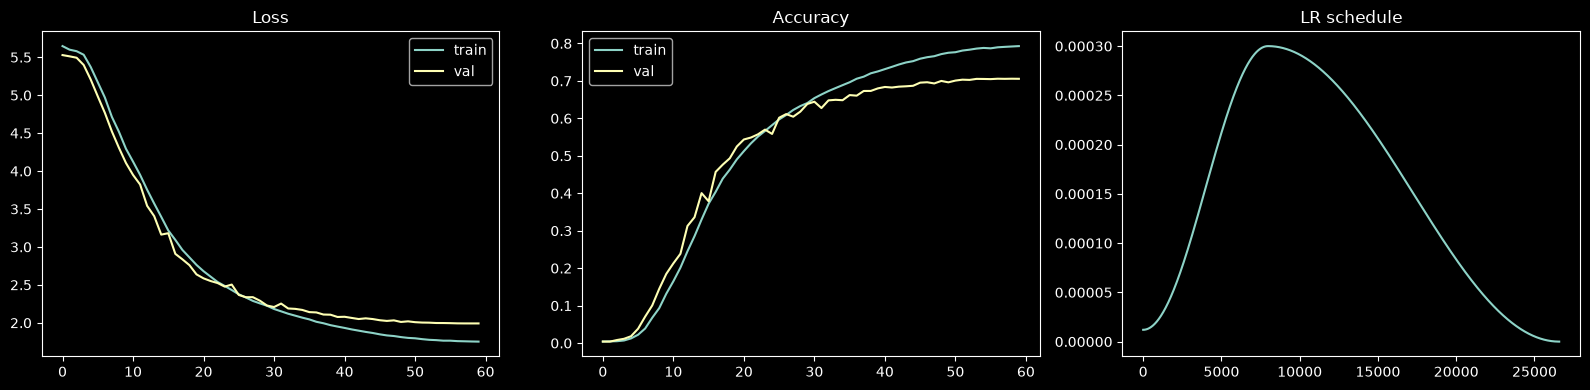

In [12]:
# ============================================================
# CELL 11 — Learning curves
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].legend()
axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_title("Accuracy")
axes[1].legend()
axes[2].plot(history["lr"])
axes[2].set_title("LR schedule")
plt.tight_layout()
plt.show()


In [13]:
# ============================================================
# CELL 12 — Export prep: reload best checkpoint, eval mode
# ============================================================
ckpt = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(ckpt["model_state"])
model.eval()


# Single-video inference wrapper: NO batch dimension, matches the
# competition's inputs=frames call exactly — (T, 543, 3) in,
# (NUM_CLASSES,) probabilities out.
class InferenceWrapper(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base = base_model

    def forward(self, frames):  # frames: (T, 543, 3)
        x = frames.reshape(1, frames.shape[0], -1)  # -> (1, T, 1629)
        x = self.base.input_norm(x)
        out, _ = self.base.gru(x)  # no packing needed, batch=1, no padding
        last = out[:, -1, :]
        logits = self.base.head(last)
        probs = torch.softmax(logits, dim=-1)
        return probs.squeeze(0)  # (NUM_CLASSES,)


infer_model = InferenceWrapper(model).to("cpu").eval()


NameError: name 'CKPT_PATH' is not defined

In [ ]:
# ============================================================
# CELL 13 — Export to ONNX with dynamic frame axis
# ============================================================
dummy_input = torch.randn(30, ROWS_PER_FRAME, 3)  # 30 is arbitrary; axis 0 is dynamic

torch.onnx.export(
    infer_model,
    dummy_input,
    "gru_model.onnx",
    input_names=["inputs"],
    output_names=["outputs"],
    dynamic_axes={"inputs": {0: "frames"}},
    opset_version=13,
)
print("ONNX export complete")


In [ ]:
# ============================================================
# CELL 14 — ONNX -> TensorFlow SavedModel
# pip install onnx2tf onnx onnxruntime tensorflow (if not already present)
# ============================================================
# !pip install onnx2tf onnx onnxruntime tensorflow --quiet

import subprocess

result = subprocess.run(
    ["onnx2tf", "-i", "gru_model.onnx", "-o", "saved_model_dir", "-osd"],
    capture_output=True,
    text=True,
)
print(result.stdout[-3000:])
print(result.stderr[-3000:])


In [ ]:
# ============================================================
# CELL 15 — Wrap SavedModel with the exact serving_default signature
# the grader expects: input "inputs" (T,543,3) -> output "outputs" (NUM_CLASSES,)
# ============================================================
import tensorflow as tf

saved_model = tf.saved_model.load("saved_model_dir")


class ServingModule(tf.Module):
    def __init__(self, saved_model):
        super().__init__()
        self.saved_model = saved_model

    @tf.function(
        input_signature=[
            tf.TensorSpec(
                shape=[None, ROWS_PER_FRAME, 3], dtype=tf.float32, name="inputs"
            )
        ]
    )
    def serving_default(self, inputs):
        result = self.saved_model(
            inputs
        )  # adapt key access if onnx2tf names differently
        if isinstance(result, dict):
            result = list(result.values())[0]
        return {"outputs": result}


serving_module = ServingModule(saved_model)
tf.saved_model.save(
    serving_module,
    "final_saved_model",
    signatures={"serving_default": serving_module.serving_default},
)


In [ ]:
# ============================================================
# CELL 16 — Convert to TFLite
# ============================================================
converter = tf.lite.TFLiteConverter.from_saved_model("final_saved_model")
converter.optimizations = [tf.lite.Optimize.DEFAULT]  # helps with the 40MB cap
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS,  # GRU dynamic-loop ops sometimes need this fallback
]
tflite_model = converter.convert()

with open("model.tflite", "wb") as f:
    f.write(tflite_model)

size_mb = os.path.getsize("model.tflite") / (1024 * 1024)
print(f"model.tflite size: {size_mb:.2f} MB (limit: 40 MB)")


In [ ]:
# ============================================================
# CELL 17 — Validate with tflite_runtime, exactly as the grader will call it
# pip install tflite-runtime  (or use tf.lite.Interpreter if that package
# isn't available on Windows — behavior is equivalent for this check)
# ============================================================
try:
    import tflite_runtime.interpreter as tflite
except ImportError:
    import tensorflow.lite as tflite  # fallback for local validation only

interpreter = tflite.Interpreter(model_path="model.tflite")
found_signatures = list(interpreter.get_signature_list().keys())
print("Signatures:", found_signatures)
assert "serving_default" in found_signatures

prediction_fn = interpreter.get_signature_runner("serving_default")

# Pull one real validation video, run through load_relevant_data_subset,
# time it to check the 100ms/video budget.
sample_path = DATA_DIR / val_split.iloc[0]["path"]
sample_frames = load_relevant_data_subset(sample_path)
sample_frames = np.nan_to_num(sample_frames, nan=0.0)

t0 = time.perf_counter()
output = prediction_fn(inputs=sample_frames)
elapsed_ms = (time.perf_counter() - t0) * 1000
print(f"Inference time: {elapsed_ms:.1f} ms (limit: 100 ms)")

pred_idx = int(np.argmax(output["outputs"]))
print(f"Predicted: {idx2sign[pred_idx]} | Actual: {val_split.iloc[0]['sign']}")
